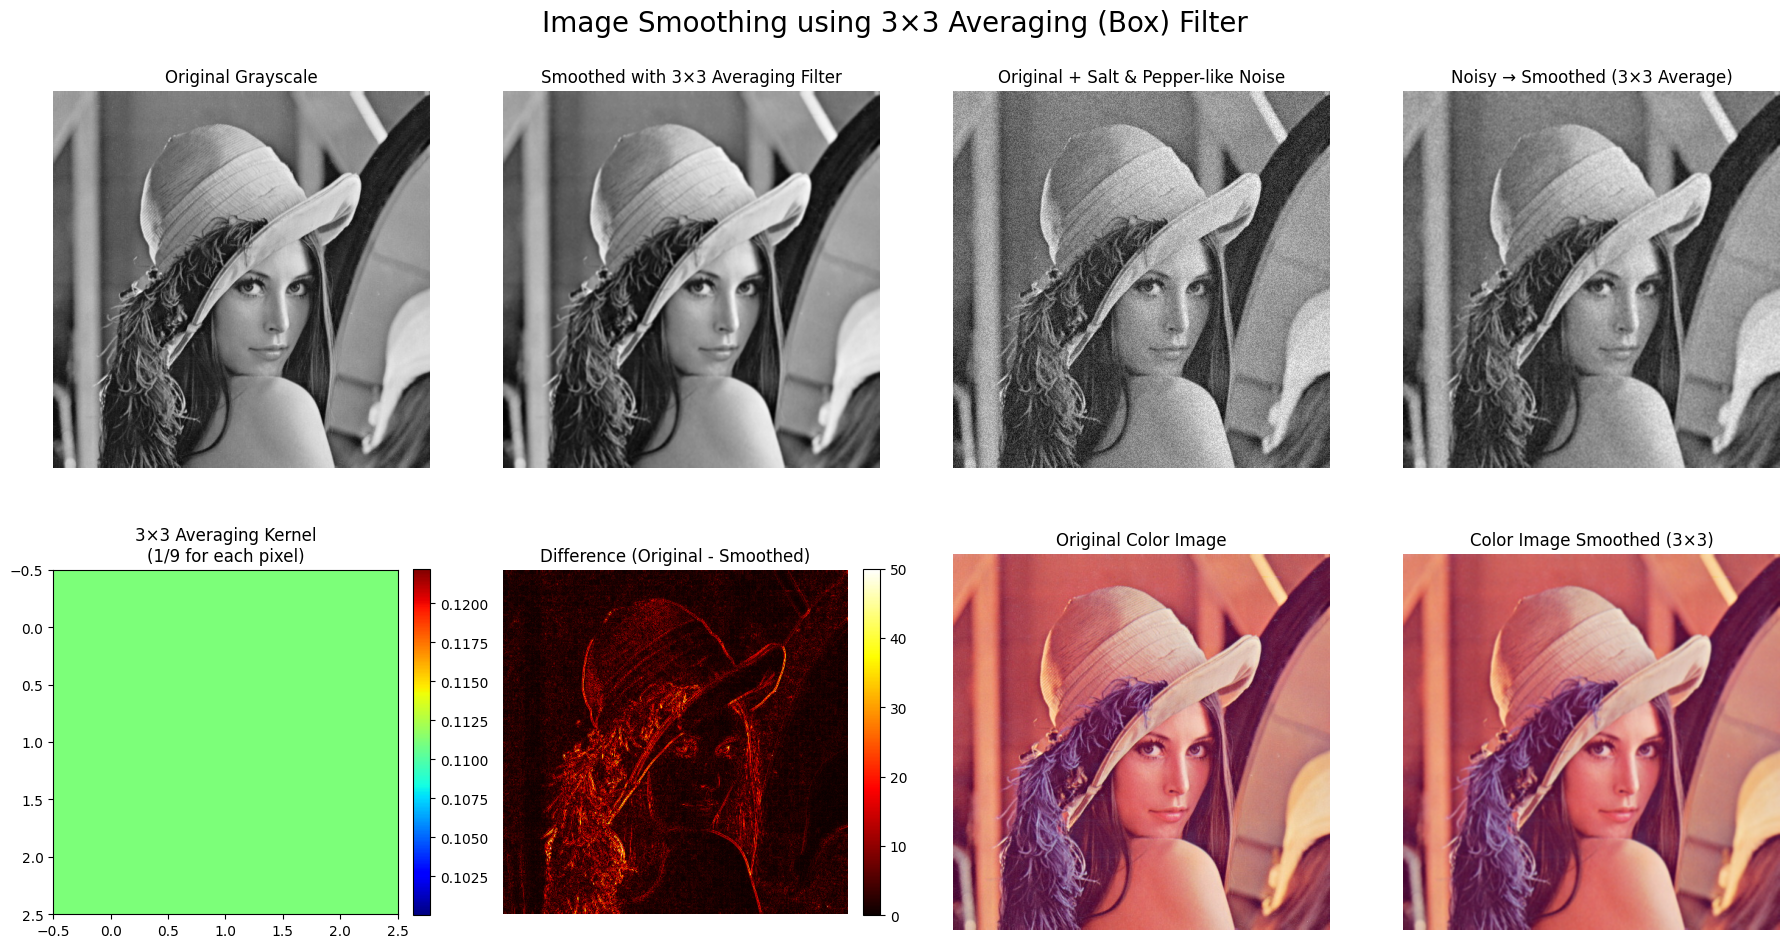

3×3 Averaging filter applied successfully!
Kernel used:
 [[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import urllib.request

# Load image
img = cv2.imread('lena.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ================================================
# 1. Manual 3x3 Averaging (for educational purpose)
# ================================================
def average_filter_manual(image):
    h, w = image.shape
    output = np.zeros_like(image)
    
    # Pad the image to handle borders
    padded = np.pad(image, pad_width=1, mode='edge')  # or 'constant', 'reflect', etc.
    
    for y in range(h):
        for x in range(w):
            # Extract 3x3 neighborhood
            neighborhood = padded[y:y+3, x:x+3]
            # Compute average
            output[y, x] = np.mean(neighborhood)
    
    return output.astype(np.uint8)

smoothed_manual = average_filter_manual(gray)

# ================================================
# 2. Using cv2.filter2D() with explicit 3x3 averaging kernel
# ================================================
kernel_3x3 = np.ones((3,3), np.float32) / 9.0   # This is the averaging kernel

smoothed_filter2d = cv2.filter2D(gray, -1, kernel_3x3)   # -1 means same depth as input

# ================================================
# 3. Fastest way: cv2.blur() or cv2.boxFilter()
# ================================================
smoothed_fast = cv2.blur(gray, (3,3))        # Exactly same as averaging with 3x3
# or: smoothed_fast = cv2.boxFilter(gray, -1, (3,3), normalize=True)

# ================================================
# Add some noise to show smoothing effect clearly
# ================================================
noise = np.random.randint(-30, 31, gray.shape, dtype=np.int16)
noisy = np.clip(gray.astype(np.int16) + noise, 0, 255).astype(np.uint8)

noisy_smoothed = cv2.blur(noisy, (3,3))

# ================================================
# Display Results
# ================================================
plt.figure(figsize=(18, 10))

plt.subplot(2, 4, 1)
plt.imshow(gray, cmap='gray')
plt.title('Original Grayscale')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(smoothed_fast, cmap='gray')
plt.title('Smoothed with 3×3 Averaging Filter')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(noisy, cmap='gray')
plt.title('Original + Salt & Pepper-like Noise')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(noisy_smoothed, cmap='gray')
plt.title('Noisy → Smoothed (3×3 Average)')
plt.axis('off')

# Show the kernel
plt.subplot(2, 4, 5)
plt.imshow(kernel_3x3, cmap='jet', interpolation='nearest')
plt.title('3×3 Averaging Kernel\n(1/9 for each pixel)')
plt.colorbar(fraction=0.046, pad=0.04)

# Difference image (to see what was removed)
diff = cv2.absdiff(gray, smoothed_fast)
plt.subplot(2, 4, 6)
plt.imshow(diff, cmap='hot', vmin=0, vmax=50)
plt.title('Difference (Original - Smoothed)')
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis('off')

# Original color image
plt.subplot(2, 4, 7)
plt.imshow(img_rgb)
plt.title('Original Color Image')
plt.axis('off')

# Color image smoothed
smoothed_color = cv2.blur(img_rgb, (3,3))
plt.subplot(2, 4, 8)
plt.imshow(smoothed_color)
plt.title('Color Image Smoothed (3×3)')
plt.axis('off')

plt.suptitle('Image Smoothing using 3×3 Averaging (Box) Filter', fontsize=20)
plt.tight_layout()
plt.show()

print("3×3 Averaging filter applied successfully!")
print("Kernel used:\n", kernel_3x3)

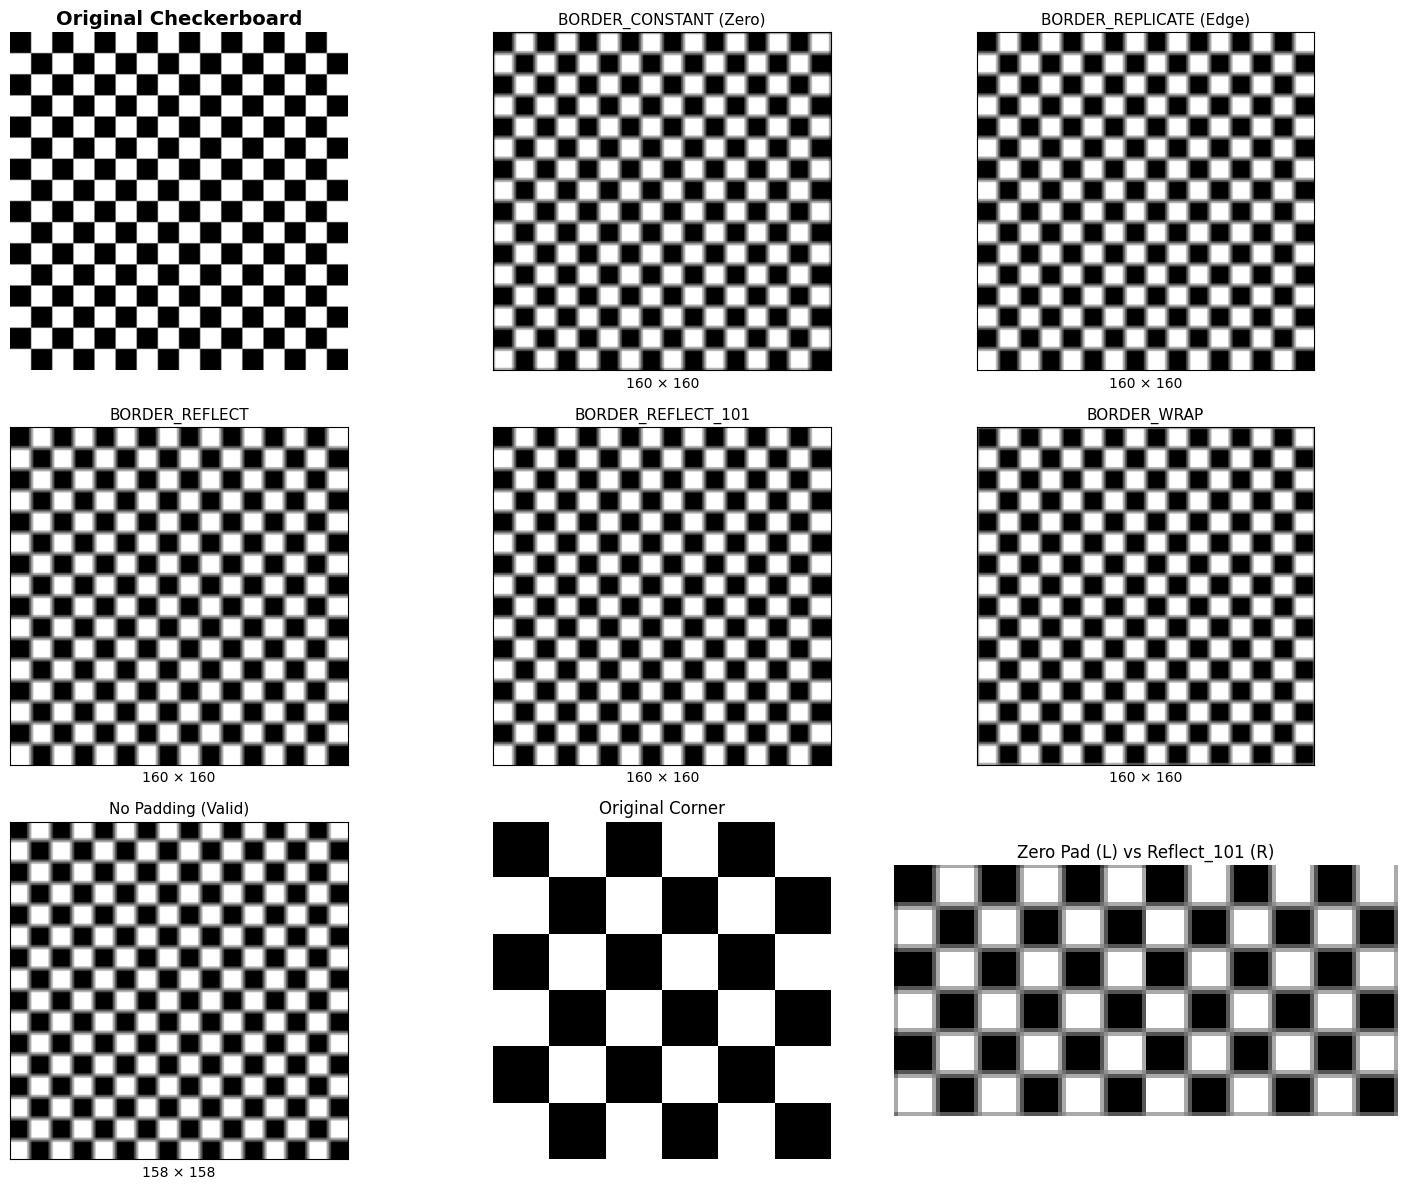

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def create_checkerboard(tile=8, blocks=8):
    row1 = np.r_[blocks * [0, 1]]
    row2 = np.r_[blocks * [1, 0]]
    board = np.vstack(blocks * (row1, row2))
    board = cv2.resize(board.astype("uint8") * 255,
                       (tile * 20, tile * 20),
                       interpolation=cv2.INTER_NEAREST)
    return board


gray = create_checkerboard()

kernel = np.ones((3,3), np.float32) / 9
pad = 1

padding_modes = [
    ("BORDER_CONSTANT (Zero)",     cv2.BORDER_CONSTANT,     0),
    ("BORDER_REPLICATE (Edge)",    cv2.BORDER_REPLICATE,    None),
    ("BORDER_REFLECT",             cv2.BORDER_REFLECT,      None),
    ("BORDER_REFLECT_101",         cv2.BORDER_REFLECT_101,  None),
    ("BORDER_WRAP",                cv2.BORDER_WRAP,         None),
    ("No Padding (Valid)",         None,                    None),
]

results = []

for name, border_type, const_value in padding_modes:

    if border_type is None:
        # VALID convolution
        full = cv2.filter2D(gray, -1, kernel, borderType=cv2.BORDER_CONSTANT)
        cropped = full[pad:-pad, pad:-pad]
        results.append((name, cropped))

    elif border_type == cv2.BORDER_CONSTANT:
        padded = cv2.copyMakeBorder(gray, pad, pad, pad, pad,
                                    borderType=cv2.BORDER_CONSTANT,
                                    value=0)
        full = cv2.filter2D(padded, -1, kernel,
                            borderType=cv2.BORDER_CONSTANT)
        results.append((name, full[pad:-pad, pad:-pad]))

    elif border_type == cv2.BORDER_WRAP:
        padded = cv2.copyMakeBorder(gray, pad, pad, pad, pad,
                                    borderType=cv2.BORDER_WRAP)
        full = cv2.filter2D(padded, -1, kernel,
                            borderType=cv2.BORDER_REPLICATE)
        results.append((name, full[pad:-pad, pad:-pad]))

    else:
        # OpenCV-supported padding
        filtered = cv2.filter2D(gray, -1, kernel, borderType=border_type)
        results.append((name, filtered))

plt.figure(figsize=(15,12))

# Original
plt.subplot(3,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Checkerboard", fontsize=14, fontweight='bold')
plt.axis('off')

# Show padding results
for i, (title, img) in enumerate(results, start=2):
    h, w = img.shape
    plt.subplot(3,3,i)
    plt.imshow(img, cmap='gray')
    plt.title(title, fontsize=11)
    plt.xlabel(f"{w} × {h}")
    plt.xticks([]), plt.yticks([])

zoom_y, zoom_x, size = 0, 0, 60

padded0 = cv2.copyMakeBorder(gray, pad, pad, pad, pad,
                            borderType=cv2.BORDER_CONSTANT, value=0)
zero_full = cv2.filter2D(padded0, -1, kernel, borderType=cv2.BORDER_CONSTANT)
zero = zero_full[pad:-pad, pad:-pad]

reflect = cv2.filter2D(gray, -1, kernel, borderType=cv2.BORDER_REFLECT_101)

plt.subplot(3,3,8)
plt.imshow(gray[zoom_y:zoom_y+size, zoom_x:zoom_x+size], cmap='gray')
plt.title("Original Corner")
plt.axis('off')

plt.subplot(3,3,9)
plt.imshow(np.hstack([
    zero[zoom_y:zoom_y+size, zoom_x:zoom_x+size],
    reflect[zoom_y:zoom_y+size, zoom_x:zoom_x+size]
]), cmap='gray')
plt.title("Zero Pad (L) vs Reflect_101 (R)")
plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import os


#img = cv2.imread('lena.jpg')
#gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


# Generate checkerboard
def create_checkerboard(size=8, num_tiles=8):
    re = np.r_[num_tiles*[0,1]]            # row pattern 0 1 0 1 ...
    ro = np.r_[num_tiles*[1,0]]            # row pattern 1 0 1 0 ...
    board = np.vstack(num_tiles*(re, ro))
    board = cv2.resize(board.astype("uint8")*255, (size*20, size*20), interpolation=cv2.INTER_NEAREST)
    return board

img = create_checkerboard()
cv2.imwrite("checkerboard.png", img)
gray = cv2.imread('checkerboard.png')


img = np.ones((300,300), dtype=np.uint8)*255
img[50:250, 80:220] = 0  # black rectangle
cv2.imwrite("rectangle.png", img)
gray = cv2.imread('rectangle.png')

# 3×3 averaging kernel
kernel = np.ones((3, 3), np.float32) / 9
pad = 1   # for 3×3 kernel

# Padding modes to demonstrate
padding_modes = [
    ("BORDER_CONSTANT (Zero)",     cv2.BORDER_CONSTANT,     0),
    ("BORDER_REPLICATE (Edge)",    cv2.BORDER_REPLICATE,    None),
    ("BORDER_REFLECT",             cv2.BORDER_REFLECT,      None),
    ("BORDER_REFLECT_101",         cv2.BORDER_REFLECT_101,  None),
    ("BORDER_WRAP",                cv2.BORDER_WRAP,         None),
    ("No Padding (Valid)",         None,                    None),
]

results = []

for name, border_type, const_value in padding_modes:

    if border_type is None:
        # ----------------------------------------
        # VALID CONVOLUTION (manual crop)
        # ----------------------------------------
        full = cv2.filter2D(
            gray, -1, kernel,
            borderType=cv2.BORDER_CONSTANT
        )
        cropped = full[pad:-pad, pad:-pad]
        results.append((name, cropped))

    elif border_type == cv2.BORDER_CONSTANT:
        # ----------------------------------------
        # CONSTANT PADDING → must pad manually
        # filter2D in OpenCV 4.x does NOT accept borderValue
        # ----------------------------------------
        padded = cv2.copyMakeBorder(
            gray, pad, pad, pad, pad,
            borderType=cv2.BORDER_CONSTANT,
            value=const_value
        )
        filtered_full = cv2.filter2D(
            padded, -1, kernel,
            borderType=cv2.BORDER_CONSTANT
        )
        filtered = filtered_full[pad:-pad, pad:-pad]
        results.append((name, filtered))

    elif border_type == cv2.BORDER_WRAP:
        # Manually wrap-pad
        padded = cv2.copyMakeBorder(
            gray, pad, pad, pad, pad,
            borderType=cv2.BORDER_WRAP
        )
    
        # filter2D CANNOT use BORDER_WRAP → use safe border type
        filtered_full = cv2.filter2D(
            padded, -1, kernel,
            borderType=cv2.BORDER_REPLICATE
        )
    
        filtered = filtered_full[pad:-pad, pad:-pad]
        results.append((name, filtered))

# =============================================
# Visualization
# =============================================
plt.figure(figsize=(15, 12))

# Original
plt.subplot(3, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title('Original 512×512', fontsize=14, fontweight='bold')
plt.axis('off')

# Results
for i, (title, img_out) in enumerate(results, start=1):
    
    # Ensure grayscale
    if len(img_out.shape) == 3:
        img_out = cv2.cvtColor(img_out, cv2.COLOR_BGR2GRAY)

    h, w = img_out.shape  # safe now

    plt.subplot(3, 3, i)
    plt.imshow(img_out, cmap='gray')
    plt.title(title, fontsize=12)
    plt.xlabel(f'{w}×{h}', fontsize=10)
    plt.xticks([]), plt.yticks([])

# =============================================
# Zoom Comparison (Zero-pad vs Reflect_101)
# =============================================
zoom_y, zoom_x, size = 120, 120, 50

# Manual constant-padding version
padded0 = cv2.copyMakeBorder(gray, pad, pad, pad, pad,
                             borderType=cv2.BORDER_CONSTANT, value=0)
zero_full = cv2.filter2D(padded0, -1, kernel, borderType=cv2.BORDER_CONSTANT)
zero = zero_full[pad:-pad, pad:-pad]

reflect = cv2.filter2D(gray, -1, kernel, borderType=cv2.BORDER_REFLECT_101)

plt.subplot(3, 3, 8)
plt.imshow(gray[zoom_y:zoom_y+size, zoom_x:zoom_x+size], cmap='gray')
plt.title('Original Corner', fontsize=12)
plt.axis('off')

plt.subplot(3, 3, 9)
plt.imshow(np.hstack([
    zero[zoom_y:zoom_y+size, zoom_x:zoom_x+size],
    reflect[zoom_y:zoom_y+size, zoom_x:zoom_x+size]
]), cmap='gray')
plt.title('Zero-pad (L) vs Reflect_101 (R)', fontsize=11)
plt.axis('off')


plt.tight_layout()
plt.show()
